### segment anything model

In [3]:
# install
!pip3 install git+https://github.com/facebookresearch/segment-anything.git
!pip3 install opencv-python pycocotools matplotlib onnxruntime onnx
!pip3 install --upgrade 'flask==1.1.2'
!pip3 install h5py
!pip3 install scikit-image
!pip3 install nibabel
!pip3 install supervision

  Cloning https://github.com/facebookresearch/segment-anything.git to /private/var/folders/tb/rwck7h6x0915hgxbsjgwc5dw0000gn/T/pip-req-build-2m0ilco3
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /private/var/folders/tb/rwck7h6x0915hgxbsjgwc5dw0000gn/T/pip-req-build-2m0ilco3
  Resolved https://github.com/facebookresearch/segment-anything.git to commit 6fdee8f2727f4506cfbbe553e23b895e27956588
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [4]:
import torch
import torchvision
print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA is available:", torch.cuda.is_available())
import sys
!{sys.executable} -m pip install opencv-python matplotlib
!{sys.executable} -m pip install 'git+https://github.com/facebookresearch/segment-anything.git'

from pprint import pprint

import os
import nibabel as nib
import numpy as np
import h5py
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

from skimage.color import label2rgb
import pandas as pd
from torch import nn
import torch.nn.functional as F
import cv2
import json
import csv

%matplotlib inline
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator, SamPredictor
import matplotlib.patches as patches

PyTorch version: 2.0.1
Torchvision version: 0.15.2
CUDA is available: False
  Cloning https://github.com/facebookresearch/segment-anything.git to /private/var/folders/tb/rwck7h6x0915hgxbsjgwc5dw0000gn/T/pip-req-build-1j5z63ji
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /private/var/folders/tb/rwck7h6x0915hgxbsjgwc5dw0000gn/T/pip-req-build-1j5z63ji
  Resolved https://github.com/facebookresearch/segment-anything.git to commit 6fdee8f2727f4506cfbbe553e23b895e27956588
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


### understanding detection bbox

In [5]:
f_train = open("train.json")
  
dat_train = json.load(f_train)

In [6]:
categories = pd.json_normalize(dat_train["categories"])
categories

,supercategory,supercategory_id,id,name
0,Meniscal Tear,1,1,Meniscal Tear (Myxoid)
1,Meniscal Tear,1,2,Meniscal Tear (Horizontal)
2,Meniscal Tear,1,3,Meniscal Tear (Radial)
3,Meniscal Tear,1,4,Meniscal Tear (Vertical/Longitudinal)
4,Meniscal Tear,1,5,Meniscal Tear (Oblique)
5,Meniscal Tear,1,6,Meniscal Tear (Complex)
6,Meniscal Tear,1,7,Meniscal Tear (Flap)
7,Meniscal Tear,1,8,Meniscal Tear (Extrusion)
8,Ligament Tear,2,9,Ligament Tear (Low-Grade Sprain)
9,Ligament Tear,2,10,Ligament Tear (Moderate Grade Sprain or Mucoid...


In [7]:
tissues = pd.json_normalize(dat_train["tissues"])
tissue_dict = dict(zip(tissues.id, tissues.name))

In [8]:
tissues

,id,name
0,1,Meniscus
1,2,ACL
2,3,PCL
3,4,Femoral Cartilage
4,5,Patellar Cartilage
5,6,Tibial Cartilage


In [9]:
cat_dict = dict(zip(categories.id, categories.name))

In [10]:
cat_id_to_supercat_id = dict(zip(categories.id, categories.supercategory_id))

In [11]:
supercat_dict = dict(zip(categories.supercategory_id, categories.supercategory))

In [12]:
annotations_train = pd.json_normalize(dat_train["annotations"])
annotations_train

,id,image_id,category_id,tissue_id,bbox,confidence,labeler
0,1,1,3,1,"[282.0, 328.0, 90.0, 38.0, 21.0, 20.0]",3.0,2
1,2,1,6,1,"[234.0, 195.0, 106.0, 87.0, 137.0, 33.0]",3.0,2
2,3,1,8,1,"[289.0, 263.0, 134.0, 28.0, 41.0, 5.0]",2.0,2
3,4,1,6,1,"[296.0, 283.0, 32.0, 26.0, 44.0, 36.0]",2.0,2
4,5,1,8,1,"[303.0, 162.0, 34.0, 28.0, 85.0, 31.0]",4.0,2
5,6,1,10,2,"[203.0, 214.0, 73.0, 110.0, 110.0, 20.0]",2.0,2
6,7,1,12,5,"[166.0, 102.0, 66.0, 43.0, 39.0, 45.0]",3.0,2
7,8,1,13,6,"[317.0, 218.0, 35.0, 15.0, 117.0, 34.0]",3.0,2
8,9,1,14,4,"[285.0, 160.0, 37.0, 37.0, 94.0, 38.0]",3.0,2
9,10,1,13,4,"[264.0, 223.0, 91.0, 43.0, 130.0, 29.0]",3.0,2


In [13]:
annotations_train["split"] = "train"
annotations_train

,id,image_id,category_id,tissue_id,bbox,confidence,labeler,split
0,1,1,3,1,"[282.0, 328.0, 90.0, 38.0, 21.0, 20.0]",3.0,2,train
1,2,1,6,1,"[234.0, 195.0, 106.0, 87.0, 137.0, 33.0]",3.0,2,train
2,3,1,8,1,"[289.0, 263.0, 134.0, 28.0, 41.0, 5.0]",2.0,2,train
3,4,1,6,1,"[296.0, 283.0, 32.0, 26.0, 44.0, 36.0]",2.0,2,train
4,5,1,8,1,"[303.0, 162.0, 34.0, 28.0, 85.0, 31.0]",4.0,2,train
5,6,1,10,2,"[203.0, 214.0, 73.0, 110.0, 110.0, 20.0]",2.0,2,train
6,7,1,12,5,"[166.0, 102.0, 66.0, 43.0, 39.0, 45.0]",3.0,2,train
7,8,1,13,6,"[317.0, 218.0, 35.0, 15.0, 117.0, 34.0]",3.0,2,train
8,9,1,14,4,"[285.0, 160.0, 37.0, 37.0, 94.0, 38.0]",3.0,2,train
9,10,1,13,4,"[264.0, 223.0, 91.0, 43.0, 130.0, 29.0]",3.0,2,train


In [14]:
# f_val = open("val.json")
  
# dat_val = json.load(f_val)

# annotations_val = pd.json_normalize(dat_val["annotations"])
# annotations_val["split"] = "val"
# annotations_val

In [15]:
# annotations = pd.concat([annotations_train, annotations_val, annotations_test])
annotations = annotations_train

In [16]:
annotations["category"] = annotations["category_id"].map(cat_dict)
annotations["supercat_id"] = annotations["category_id"].map(cat_id_to_supercat_id) 
annotations["supercategory"] = annotations["supercat_id"].map(supercat_dict) 
annotations["tissues"] = annotations["tissue_id"].map(tissue_dict)
annotations

,id,image_id,category_id,tissue_id,bbox,confidence,labeler,split,category,supercat_id,supercategory,tissues
0,1,1,3,1,"[282.0, 328.0, 90.0, 38.0, 21.0, 20.0]",3.0,2,train,Meniscal Tear (Radial),1,Meniscal Tear,Meniscus
1,2,1,6,1,"[234.0, 195.0, 106.0, 87.0, 137.0, 33.0]",3.0,2,train,Meniscal Tear (Complex),1,Meniscal Tear,Meniscus
2,3,1,8,1,"[289.0, 263.0, 134.0, 28.0, 41.0, 5.0]",2.0,2,train,Meniscal Tear (Extrusion),1,Meniscal Tear,Meniscus
3,4,1,6,1,"[296.0, 283.0, 32.0, 26.0, 44.0, 36.0]",2.0,2,train,Meniscal Tear (Complex),1,Meniscal Tear,Meniscus
4,5,1,8,1,"[303.0, 162.0, 34.0, 28.0, 85.0, 31.0]",4.0,2,train,Meniscal Tear (Extrusion),1,Meniscal Tear,Meniscus
5,6,1,10,2,"[203.0, 214.0, 73.0, 110.0, 110.0, 20.0]",2.0,2,train,Ligament Tear (Moderate Grade Sprain or Mucoid...,2,Ligament Tear,ACL
6,7,1,12,5,"[166.0, 102.0, 66.0, 43.0, 39.0, 45.0]",3.0,2,train,Cartilage Lesion (1),3,Cartilage Lesion,Patellar Cartilage
7,8,1,13,6,"[317.0, 218.0, 35.0, 15.0, 117.0, 34.0]",3.0,2,train,Cartilage Lesion (2A),3,Cartilage Lesion,Tibial Cartilage
8,9,1,14,4,"[285.0, 160.0, 37.0, 37.0, 94.0, 38.0]",3.0,2,train,Cartilage Lesion (2B),3,Cartilage Lesion,Femoral Cartilage
9,10,1,13,4,"[264.0, 223.0, 91.0, 43.0, 130.0, 29.0]",3.0,2,train,Cartilage Lesion (2A),3,Cartilage Lesion,Femoral Cartilage


In [17]:
example = annotations[["image_id", "bbox", "supercat_id", "supercategory"]]

In [18]:
# [top left X position, top left Y position, top left Z position, deltaX, deltaY, deltaZ]
# [x_min, y_min, x_max, y_max]


In [19]:
# del example['s_min']

In [20]:
# example['s_min'] = example.apply(bbox_to_s_min, axis=1)

example['s_max'] = example['bbox'].apply(lambda x: x[2] + x[5]).astype('int32')
example['s_min'] = example['bbox'].apply(lambda x: x[2]).astype('int32')
example['y_max'] = example['bbox'].apply(lambda x: x[0] + x[3]).astype('int32')
example['y_min'] = example['bbox'].apply(lambda x: x[0]).astype('int32')
example['x_max'] = example['bbox'].apply(lambda x: x[1] + x[4]).astype('int32')
example['x_min'] = example['bbox'].apply(lambda x: x[1]).astype('int32')
example['x_min_y_min'] = example['bbox'].apply(lambda x: (x[1], x[0]))
example['sam'] = example['bbox'].apply(lambda x: [x[1], x[0], x[1] + x[4], x[0] + x[3]])

/var/folders/tb/rwck7h6x0915hgxbsjgwc5dw0000gn/T/ipykernel_45245/3061135598.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  example['s_max'] = example['bbox'].apply(lambda x: x[2] + x[5]).astype('int32')
/var/folders/tb/rwck7h6x0915hgxbsjgwc5dw0000gn/T/ipykernel_45245/3061135598.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  example['s_min'] = example['bbox'].apply(lambda x: x[2]).astype('int32')
/var/folders/tb/rwck7h6x0915hgxbsjgwc5dw0000gn/T/ipykernel_45245/3061135598.py:5: SettingWithCopyWarnin

In [21]:
example

,image_id,bbox,supercat_id,supercategory,s_max,s_min,y_max,y_min,x_max,x_min,x_min_y_min,sam
0,1,"[282.0, 328.0, 90.0, 38.0, 21.0, 20.0]",1,Meniscal Tear,110,90,320,282,349,328,"(328.0, 282.0)","[328.0, 282.0, 349.0, 320.0]"
1,1,"[234.0, 195.0, 106.0, 87.0, 137.0, 33.0]",1,Meniscal Tear,139,106,321,234,332,195,"(195.0, 234.0)","[195.0, 234.0, 332.0, 321.0]"
2,1,"[289.0, 263.0, 134.0, 28.0, 41.0, 5.0]",1,Meniscal Tear,139,134,317,289,304,263,"(263.0, 289.0)","[263.0, 289.0, 304.0, 317.0]"
3,1,"[296.0, 283.0, 32.0, 26.0, 44.0, 36.0]",1,Meniscal Tear,68,32,322,296,327,283,"(283.0, 296.0)","[283.0, 296.0, 327.0, 322.0]"
4,1,"[303.0, 162.0, 34.0, 28.0, 85.0, 31.0]",1,Meniscal Tear,65,34,331,303,247,162,"(162.0, 303.0)","[162.0, 303.0, 247.0, 331.0]"
5,1,"[203.0, 214.0, 73.0, 110.0, 110.0, 20.0]",2,Ligament Tear,93,73,313,203,324,214,"(214.0, 203.0)","[214.0, 203.0, 324.0, 313.0]"
6,1,"[166.0, 102.0, 66.0, 43.0, 39.0, 45.0]",3,Cartilage Lesion,111,66,209,166,141,102,"(102.0, 166.0)","[102.0, 166.0, 141.0, 209.0]"
7,1,"[317.0, 218.0, 35.0, 15.0, 117.0, 34.0]",3,Cartilage Lesion,69,35,332,317,335,218,"(218.0, 317.0)","[218.0, 317.0, 335.0, 332.0]"
8,1,"[285.0, 160.0, 37.0, 37.0, 94.0, 38.0]",3,Cartilage Lesion,75,37,322,285,254,160,"(160.0, 285.0)","[160.0, 285.0, 254.0, 322.0]"
9,1,"[264.0, 223.0, 91.0, 43.0, 130.0, 29.0]",3,Cartilage Lesion,120,91,307,264,353,223,"(223.0, 264.0)","[223.0, 264.0, 353.0, 307.0]"


In [22]:
sl = 80 # slice # to view

In [23]:
example = example[example['s_max'] >= sl]

In [24]:
example = example[example['s_min'] <= sl]
example

,image_id,bbox,supercat_id,supercategory,s_max,s_min,y_max,y_min,x_max,x_min,x_min_y_min,sam
5,1,"[203.0, 214.0, 73.0, 110.0, 110.0, 20.0]",2,Ligament Tear,93,73,313,203,324,214,"(214.0, 203.0)","[214.0, 203.0, 324.0, 313.0]"
6,1,"[166.0, 102.0, 66.0, 43.0, 39.0, 45.0]",3,Cartilage Lesion,111,66,209,166,141,102,"(102.0, 166.0)","[102.0, 166.0, 141.0, 209.0]"
10,1,"[182.0, 121.0, 60.0, 96.0, 39.0, 39.0]",3,Cartilage Lesion,99,60,278,182,160,121,"(121.0, 182.0)","[121.0, 182.0, 160.0, 278.0]"


### Visualize bbox

In [40]:
# adapted from meddlr
def one_hot_to_categorical(x, channel_dim: int = 1, background=False):
    """Converts one-hot encoded predictions to categorical predictions.

    Args:
        x (torch.Tensor | np.ndarray): One-hot encoded predictions.
        channel_dim (int, optional): Channel dimension.
            Defaults to ``1`` (i.e. ``(B,C,...)``).
        background (bool, optional): If ``True``, assumes index 0 in the
            channel dimension is the background.

    Returns:
        torch.Tensor | np.ndarray: Categorical array or tensor. If ``background=False``,
        the output will be 1-indexed such that ``0`` corresponds to the background.
    """
    is_ndarray = isinstance(x, np.ndarray)
    if is_ndarray:
        x = torch.as_tensor(x)

    if background is not None and background is not False:
        out = torch.argmax(x, channel_dim)
    else:
        out = torch.argmax(x.type(torch.long), dim=channel_dim) + 1
        out = torch.where(x.sum(channel_dim) == 0, torch.tensor([0], device=x.device), out)

    if is_ndarray:
        out = out.numpy()
    return out

In [41]:
with h5py.File("skm-tea/MTR_030.h5", "r") as f:
    # Print all root level object names (aka keys) 
    # these can be group or dataset names 
    print("Keys: %s" % f.keys())
    
    # get first object name/key; may or may NOT be a group
    a_group_key = list(f.keys())[0]
    # get the object type for a_group_key: usually group or dataset
    print(type(f[a_group_key])) 
    
    # If a_group_key is a group name, 
    # this gets the object names in the group and returns as a list
    data = list(f[a_group_key])

    # If a_group_key is a dataset name, 
    # this gets the dataset values and returns as a list
    data = list(f[a_group_key])
    # preferred methods to get dataset values:
    ds_obj = f[a_group_key]      # returns as a h5py dataset object
    ds_arr = f[a_group_key][()]  # returns as a numpy array

Keys: <KeysViewHDF5 ['echo1', 'echo2', 'seg', 'stats']>
<class 'h5py._hl.dataset.Dataset'>


In [42]:
test = "skm-tea/MTR_030"
train = "skm-tea/MTR_201"
val = "skm-tea/MTR_184"

with h5py.File(train  + ".h5", "r") as f:
    echo1 = f["echo1"][:, :, sl]
    echo2 = f["echo2"][:, :, sl]
    seg = f["seg"][:, :, sl, :]

In [43]:
segmentation = one_hot_to_categorical(seg, channel_dim=-1)
segmentation.shape

(512, 512)

In [44]:
seg_colorized = label2rgb(segmentation, bg_label=0, bg_color=None)
seg_colorized.shape

(512, 512, 3)

In [45]:
# echo1_scaled = cv2.normalize(echo1, None, 0, 1, cv2.NORM_MINMAX, dtype=cv2.CV_32F) / 255
# echo2_scaled = cv2.normalize(echo2, None, 0, 1, cv2.NORM_MINMAX, dtype=cv2.CV_32F) / 255

echo1_scaled = cv2.normalize(echo1, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_32F)
echo2_scaled = cv2.normalize(echo2, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_32F)

dimensions are: (214.0, 203.0) 110.0 110.0
dimensions are: (102.0, 166.0) 39.0 43.0
dimensions are: (121.0, 182.0) 39.0 96.0


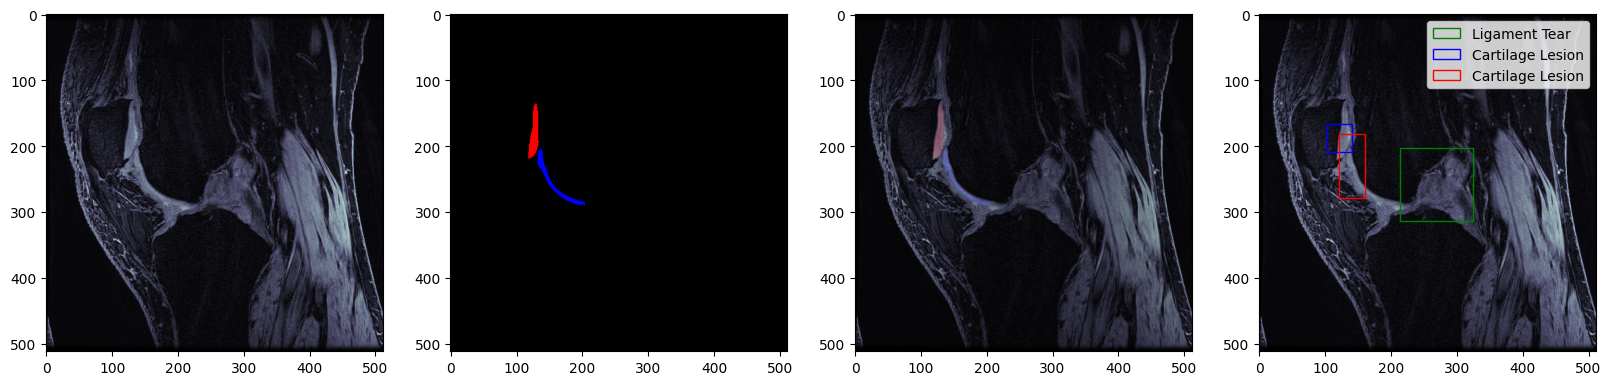

In [46]:
fig, axes = plt.subplots(1, 4, figsize = (20, 20))
axes[0].imshow(echo1, cmap = plt.cm.bone)
axes[1].imshow(seg_colorized)
axes[2].imshow(echo1_scaled, cmap = plt.cm.bone)
axes[2].imshow(seg_colorized, alpha = 0.2)
axes[3].imshow(echo1_scaled, cmap = plt.cm.bone)

color = ['g', 'b', 'r', 'y', 'c', 'm']
i = 0
for index, row in example.iterrows():
    rect = patches.Rectangle(row["x_min_y_min"], row["bbox"][4], row["bbox"][3], linewidth=1, edgecolor=color[i], facecolor='none', label=row["supercategory"])
    axes[3].add_patch(rect)
    i = i + 1
    print("dimensions are:", row["x_min_y_min"], row["bbox"][4], row["bbox"][3])

axes[3].legend()

In [47]:
file_name_echo1 = train + "_" + str(sl) + "_echo1_scaled.png"
file_name_echo2 = train + "_" + str(sl) + "_echo2_scaled.png"
cv2.imwrite(file_name_echo1, echo1_scaled) # save image
cv2.imwrite(file_name_echo2, echo2_scaled) # save image

True

### Convert segmentation pixels to bbox

In [49]:
segmentation

(512, 512)

In [50]:
segmentation.nonzero()

(array([136, 136, 137, ..., 289, 289, 289]),
 array([129, 130, 129, ..., 202, 203, 204]))

In [51]:
np.unique(segmentation)

array([0, 1, 2])

In [54]:
segmentation_idx_set = [np.argwhere(i==segmentation) for i in np.unique(segmentation)]

In [55]:
len(segmentation_idx_set)

3

In [56]:
segmentation_idx_set[1][0:5]

array([[136, 129],
       [136, 130],
       [137, 129],
       [137, 130],
       [137, 131]])

In [57]:
segmentation_idx_set[1]

array([[136, 129],
       [136, 130],
       [137, 129],
       ...,
       [218, 121],
       [218, 122],
       [219, 119]])

In [59]:
segmentation_idx_set

[array([[  0,   0],
        [  0,   1],
        [  0,   2],
        ...,
        [511, 509],
        [511, 510],
        [511, 511]]),
 array([[136, 129],
        [136, 130],
        [137, 129],
        ...,
        [218, 121],
        [218, 122],
        [219, 119]]),
 array([[204, 137],
        [204, 138],
        [205, 136],
        ...,
        [289, 202],
        [289, 203],
        [289, 204]])]

In [81]:
segmentation_flipped = []
for i in range(len(segmentation_idx_set) - 1):
    list_x = [i[1] for i in segmentation_idx_set[i + 1]]
    list_y = [i[0] for i in segmentation_idx_set[i + 1]]
    input_points = np.array(list(zip(list_x, list_y)))
    segmentation_flipped.append(input_points)

In [114]:
np.sort(segmentation_flipped[0], axis = 0)

array([[119, 136],
       [119, 136],
       [119, 137],
       ...,
       [134, 218],
       [134, 218],
       [134, 219]])

In [113]:
segmentation_flipped[0]

array([[129, 136],
       [130, 136],
       [129, 137],
       ...,
       [121, 218],
       [122, 218],
       [119, 219]])

In [117]:
bbox = []
x_min, y_min, x_max, y_max = 0, 0, 0, 0
for pixel in segmentation_flipped:

    y_min = pixel[0][1]
    y_max = pixel[-1][1]

    pixel_sorted = np.sort(pixel, axis = 0)
    x_min = pixel_sorted[0][0]
    x_max = pixel_sorted[-1][0]
    
    # for each in pixel:
    #     if each[0] < x_min:
    #         x_min = each[0]
    #     if each[0] > x_max:
    #         x_max = each[0]

    bbox.append([(x_min, y_min), x_max - x_min, y_max - y_min])
    print(bbox)

[[(119, 136), 15, 83]]
[[(119, 136), 15, 83], [(133, 204), 71, 85]]


### Visualize segmentation bbox with pathology tears

dimensions are: (119, 136) 15 83
dimensions are: (133, 204) 71 85
dimensions are: (214.0, 203.0) 110.0 110.0
dimensions are: (102.0, 166.0) 39.0 43.0
dimensions are: (121.0, 182.0) 39.0 96.0


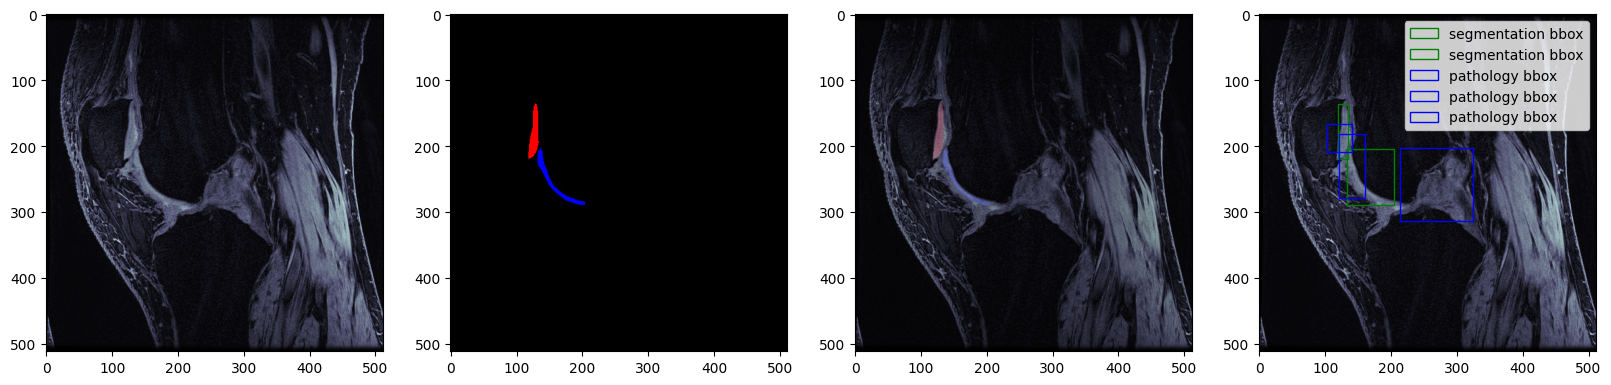

In [119]:
fig, axes = plt.subplots(1, 4, figsize = (20, 20))
axes[0].imshow(echo1, cmap = plt.cm.bone)
axes[1].imshow(seg_colorized)
axes[2].imshow(echo1_scaled, cmap = plt.cm.bone)
axes[2].imshow(seg_colorized, alpha = 0.2)
axes[3].imshow(echo1_scaled, cmap = plt.cm.bone)


for each in bbox:
    rect = patches.Rectangle(each[0], each[1], each[2], linewidth=1, edgecolor='g', facecolor='none', label='segmentation bbox')
    axes[3].add_patch(rect)
    print("dimensions are:", each[0], each[1], each[2])

for index, row in example.iterrows():
    rect = patches.Rectangle(row["x_min_y_min"], row["bbox"][4], row["bbox"][3], linewidth=1, edgecolor='b', facecolor='none', label='pathology bbox')
    axes[3].add_patch(rect)
    print("dimensions are:", row["x_min_y_min"], row["bbox"][4], row["bbox"][3])

axes[3].legend()

### Load SAM

In [323]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
sam_checkpoint_1 = "sam_vit_h_4b8939.pth"
sam_checkpoint_2 = "sam_vit_b_01ec64.pth"
sam_checkpoint_3 = "sam_vit_l_0b3195.pth"

model_type_1 = "vit_h"
model_type_2 = "vit_b"
model_type_3 = "vit_l"

In [286]:
## set checkpoint & model 
sam_checkpoint_final = sam_checkpoint_2
model_type_final = model_type_2

In [287]:
!pwd
home = '/Users/cindy/Desktop/mids/w210'

/Users/Cindy/Desktop/mids/w210


In [288]:
import os

sam_checkpoint = os.path.join(home, sam_checkpoint_final)
print(sam_checkpoint, "; exist:", os.path.isfile(sam_checkpoint))
model_type = model_type_final

/Users/cindy/Desktop/mids/w210/sam_vit_b_01ec64.pth ; exist: True


In [289]:
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator, SamPredictor

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint).to(device=device)

### SAM with points

In [331]:
def show_points(coords, labels, ax, marker_size=375):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='.', s=marker_size, edgecolor='red', linewidth=0.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='yellow', marker='.', s=marker_size, edgecolor='yellow', linewidth=0.25)  

def show_mask(mask, ax, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)

def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0,0,0,0), lw=2))    

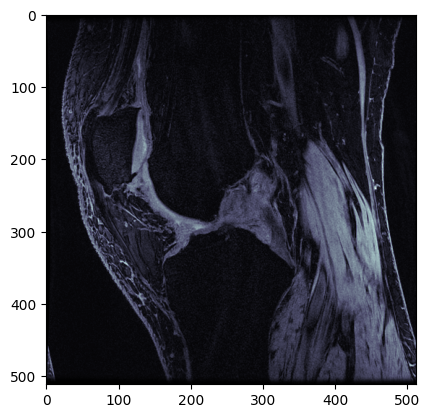

In [325]:
path = file_name_echo1
img = cv2.imread(path, 0)
# img = echo1_scaled
# plt.imshow(img, cmap='gray')
plt.imshow(img, cmap=plt.cm.bone)

In [304]:
image_array = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
image_array = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

predictor = SamPredictor(sam)
predictor.set_image(image_array)

In [327]:
example["sam"]

5     [214.0, 203.0, 324.0, 313.0]
6     [102.0, 166.0, 141.0, 209.0]
10    [121.0, 182.0, 160.0, 278.0]
Name: sam, dtype: object

In [333]:
len(example)

3

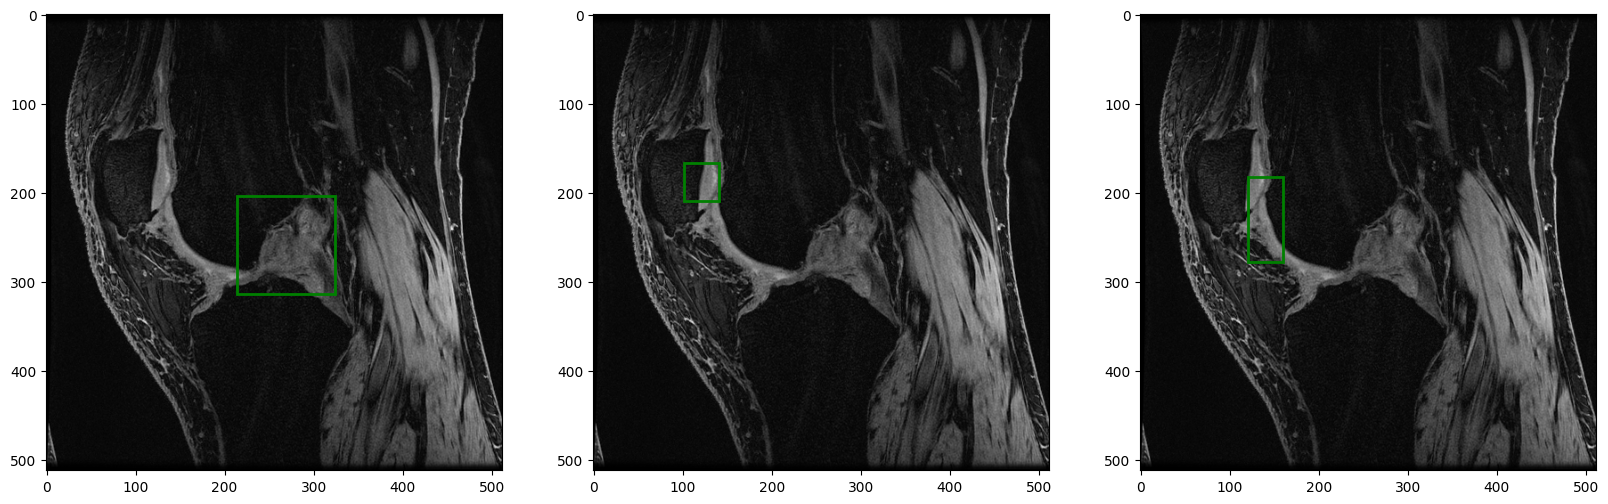

In [337]:
fig, axes = plt.subplots(1, len(example), figsize = (20, 20))

i = 0
for idx, row in example.iterrows():
    axes[i].imshow(image_array, cmap = plt.cm.bone)
    input_box = np.array(example["sam"][idx])
    show_box(input_box, axes[i])
    axes[i].axis("on")
    # plt.show()
    i = i + 1

Ligament Tear
Cartilage Lesion
Cartilage Lesion


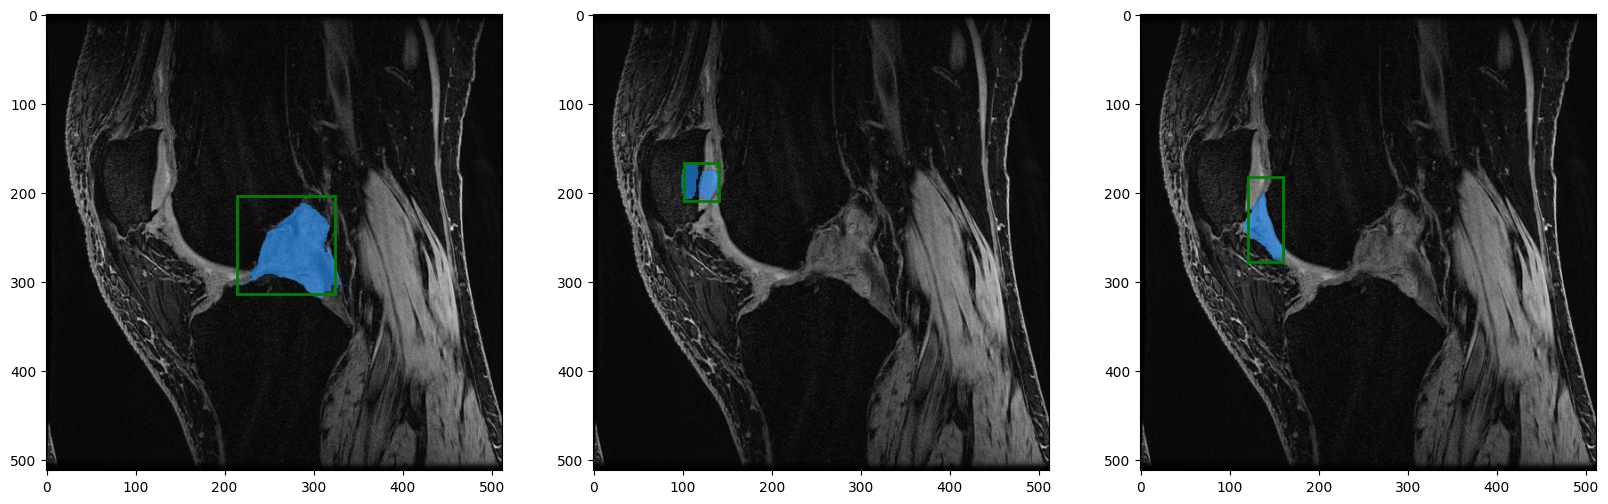

In [403]:
fig, axes = plt.subplots(1, len(example), figsize = (20, 20))

i = 0
for idx, row in example.iterrows():

    axes[i].imshow(image_array, cmap = plt.cm.bone)
    input_box = np.array(example["sam"][idx])
    show_box(input_box, axes[i])

    masks, _, _ = predictor.predict(
        point_coords=None,
        point_labels=None,
        box=input_box[None, :],
        multimask_output=False,
    )
    
    show_mask(masks[0], axes[i])
    axes[i].axis("on")
    # plt.show()
    print(example["supercategory"][idx])
    i = i + 1

### Incorporate annotations

In [406]:
# https://colab.research.google.com/github/roboflow-ai/notebooks/blob/main/notebooks/how-to-segment-anything-with-sam.ipynb#scrollTo=RHw4yH8XRCo9
import supervision as sv
from supervision import Detections

In [405]:
def annotations2detections(df) -> Detections:
    class_id, xyxy = [], []

    for idx, row in example.iterrows():
        y_min, x_min, z_min, height, width, depth = example["bbox"][idx]
        class_id.append(example["supercat_id"][idx])
        xyxy.append([
            x_min,
            y_min,
            x_min + width,
            y_min + height
        ])


    return Detections(
        xyxy=np.array(xyxy, dtype=int),
        class_id=np.array(class_id, dtype=int)
    )


In [398]:
# load dataset annotations
ground_truth = annotations2detections(df=example)

# load image
image_bgr = cv2.imread(path)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

# initiate annotator
box_annotator = sv.BoxAnnotator(color=sv.Color.red())
mask_annotator = sv.MaskAnnotator(color=sv.Color.red())

# annotate ground truth
annotated_frame_ground_truth = box_annotator.annotate(scene=image_bgr.copy(), detections=ground_truth, skip_label=False)


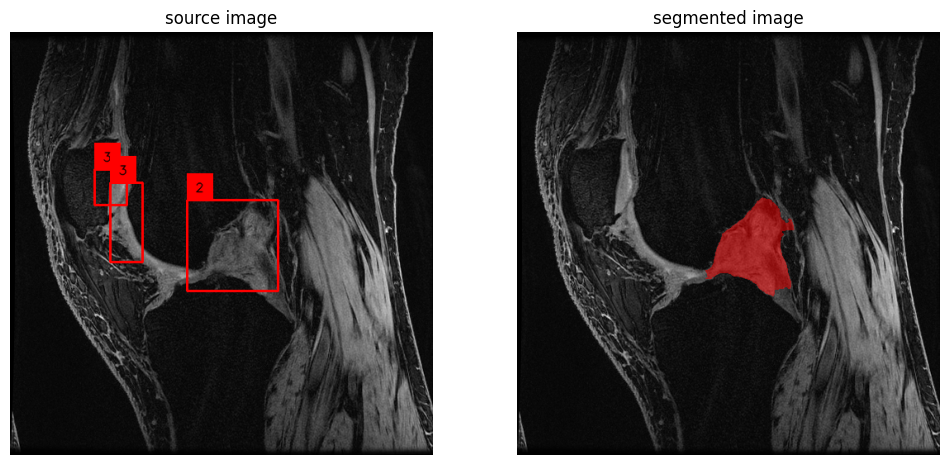

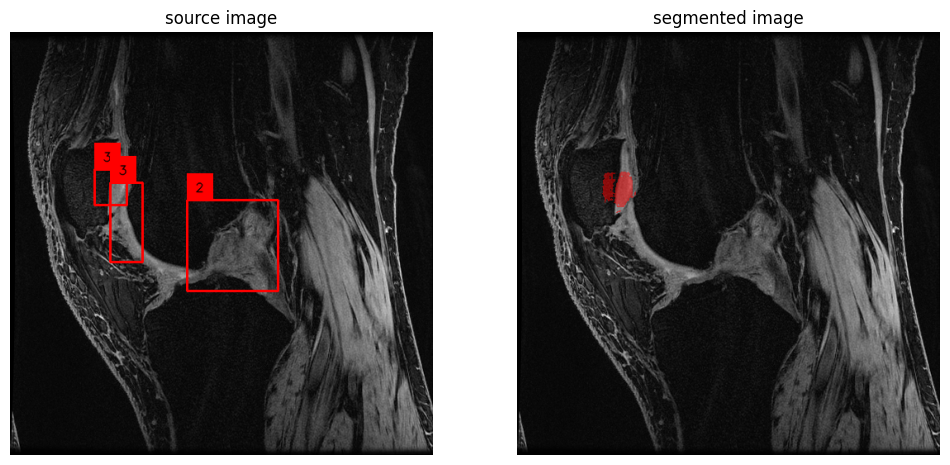

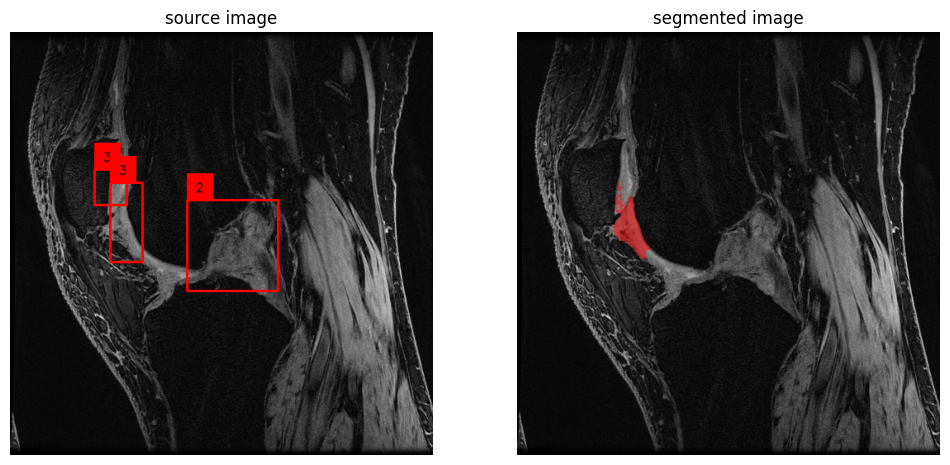

CPU times: user 9.69 s, sys: 4.18 s, total: 13.9 s
Wall time: 4.81 s


In [399]:
%%time
# run SAM inference
predictor.set_image(image_rgb)

for i in range(len(ground_truth.xyxy)):
    masks, scores, logits = predictor.predict(
        box=ground_truth.xyxy[i],
        multimask_output=True
    )

    detections = sv.Detections(
        xyxy=sv.mask_to_xyxy(masks=masks),
        mask=masks
    )

    detections = detections[detections.area == np.max(detections.area)]

    annotated_image = mask_annotator.annotate(scene=image_bgr.copy(), detections=detections)

    sv.plot_images_grid(
        images=[annotated_frame_ground_truth, annotated_image],
        grid_size=(1, 2),
        titles=['source image', 'detected image']
    )

In [404]:
annotated_frame_ground_truth.shape

(512, 512, 3)

In [408]:
annotated_image.shape

(512, 512, 3)